# Tutorial 2: The Three Flavours of SBI — NPE vs NLE vs NRE

**Course:** AI4Science — Simulation-Based Inference\
**Lecture link:** Lecture I, Part IV (comparison table)

---

### Learning objectives
- Run all three SBI algorithms on the same problem
- Compare posterior quality, training time, and inference speed

> **Runtime:** Select **GPU** in Colab


In [ ]:
!pip install -q sbi torch matplotlib

import torch, time
import numpy as np
import math
import matplotlib.pyplot as plt
from sbi.utils import BoxUniform
from sbi.inference import NPE, NLE, NRE, simulate_for_sbi
from sbi.analysis import pairplot
from sbi.utils.user_input_checks import process_prior, process_simulator, check_sbi_inputs

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


## 1. The Two Moons Simulator

**Generative process** for each sample:
1. Draw angle $\alpha \sim \mathrm{Uniform}(-\pi/2,\; \pi/2)$
2. Draw radius $r \sim \mathcal{N}(0.1,\; 0.1^2)$ — point on a noisy semicircle
3. Rotate $\theta$ by $-45°$ and take the absolute value of the first component
4. Compute: $x = (r\cos\alpha + 0.25,\; r\sin\alpha) - (|\tilde{\theta}_1|,\; -\tilde{\theta}_2)$

The **absolute value** creates bimodality: for a given observation $x_o$,
two mirror-image parameter regions ($\theta_1+\theta_2>0$ and $\theta_1+\theta_2<0$) are equally consistent.

> We use $\sigma_r = 0.1$ (wider than the original 0.01 from Greenberg et al.) to make
> the crescents thicker and easier to see in a tutorial setting.


In [ ]:
num_dim = 2
prior = BoxUniform(low=-1.0 * torch.ones(num_dim), high=1.0 * torch.ones(num_dim))

NOISE_STD = 0.01  # Width of the crescent (original paper uses 0.01; we use 0.1 for visibility)

def two_moons_simulator(theta):
    """Two Moons simulator (Greenberg et al., 2019, modified noise).

    Args:
        theta: (batch_size, 2) tensor of parameters

    Returns:
        x: (batch_size, 2) tensor of simulated data
    """
    n = theta.shape[0]

    # Step 1-2: noisy point on a semicircle
    alpha = (torch.rand(n) - 0.5) * math.pi             # U(-π/2, π/2)
    r = 0.1 + NOISE_STD * torch.randn(n)                # N(0.1, NOISE_STD²)

    p1 = r * torch.cos(alpha) + 0.25                    # semicircle x-coord
    p2 = r * torch.sin(alpha)                            # semicircle y-coord

    # Step 3: rotate θ by -π/4, then abs on first component
    t1 = -torch.abs(theta[:, 0] + theta[:, 1])/torch.sqrt(torch.tensor(2.))              # (θ₁+θ₂)/√2
    t2 = (-theta[:, 0] + theta[:, 1])/torch.sqrt(torch.tensor(2.))               # (-θ₁+θ₂)/√2

    # Step 4: data = semicircle point - rotated(|·|, ·)
    x1 = p1 + t1
    x2 = p2 + t2

    return torch.stack([x1, x2], dim=1)

def two_moons_simulator(theta):
    """Two Moons simulator (Greenberg et al., 2019, modified noise).

    Args:
        theta: (batch_size, 2) tensor of parameters

    Returns:
        x: (batch_size, 2) tensor of simulated data
    """
    n = theta.shape[0]

    # Step 1-2: noisy point on a semicircle
    alpha = (torch.rand(n) - 0.5) * math.pi             # U(-π/2, π/2)
    r = 0.1 + NOISE_STD * torch.randn(n)                # N(0.1, NOISE_STD²)

    p1 = r * torch.cos(alpha) + 0.25                    # semicircle x-coord
    p2 = r * torch.sin(alpha)                            # semicircle y-coord

    # Step 3: rotate θ by -π/4, then abs on first component
    ang = -math.pi / 4
    c, s = math.cos(ang), math.sin(ang)
    t1 = c * theta[:, 0] - s * theta[:, 1]              # (θ₁+θ₂)/√2
    t2 = s * theta[:, 0] + c * theta[:, 1]              # (-θ₁+θ₂)/√2
    t1 = torch.abs(t1)                                   # absolute value → bimodality

    # Step 4: data = semicircle point - rotated(|·|, ·)
    x1 = p1 - t1
    x2 = p2 + t2

    return torch.stack([x1, x2], dim=1)
# Validate
prior, _, prn = process_prior(prior)
simulator = process_simulator(two_moons_simulator, prior, prn)
check_sbi_inputs(simulator, prior)
print("✓ Two Moons simulator ready")


✓ Two Moons simulator ready


### Diagnostic: What does the simulator produce for a *single* θ?

Before training, let's verify the simulator works correctly.
For a **fixed** $\theta$, repeated calls should trace a **noisy semicircle** (crescent).


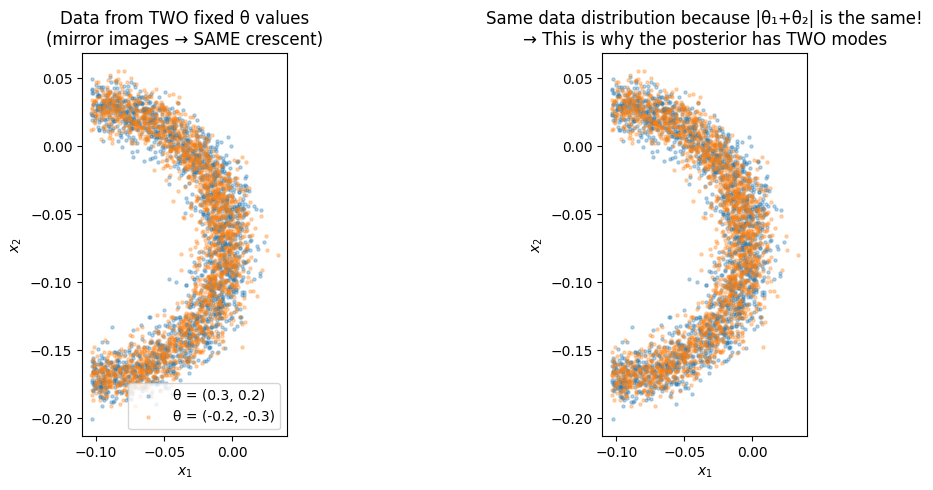

|θ₁+θ₂| for blue:   0.500
|θ₁+θ₂| for orange: 0.500
→ Same! The absolute value makes them indistinguishable from data alone.


In [ ]:
# Fix a single theta and sample many x's from the simulator
theta_fixed = torch.tensor([0.3, 0.2])
n_samples = 2000
theta_repeated = theta_fixed.unsqueeze(0).repeat(n_samples, 1)  # (2000, 2)
x_single = two_moons_simulator(theta_repeated)

# For comparison: the mirror theta (same |θ₁+θ₂| but opposite sign)
theta_mirror = torch.tensor([-0.2, -0.3])
theta_rep_mirror = theta_mirror.unsqueeze(0).repeat(n_samples, 1)
x_mirror = two_moons_simulator(theta_rep_mirror)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(x_single[:, 0].numpy(), x_single[:, 1].numpy(), alpha=0.3, s=5,
           label=f"θ = ({theta_fixed[0]:.1f}, {theta_fixed[1]:.1f})")
ax.scatter(x_mirror[:, 0].numpy(), x_mirror[:, 1].numpy(), alpha=0.3, s=5,
           label=f"θ = ({theta_mirror[0]:.1f}, {theta_mirror[1]:.1f})")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.legend(); ax.set_aspect("equal")
ax.set_title("Data from TWO fixed θ values\n(mirror images → SAME crescent)")

# Show they produce the same distribution (overlapping crescents)
ax = axes[1]
ax.scatter(x_single[:, 0].numpy(), x_single[:, 1].numpy(), alpha=0.3, s=5, color="C0")
ax.scatter(x_mirror[:, 0].numpy(), x_mirror[:, 1].numpy(), alpha=0.3, s=5, color="C1")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("Same data distribution because |θ₁+θ₂| is the same!\n→ This is why the posterior has TWO modes")
ax.set_aspect("equal")

plt.tight_layout(); plt.show()
print(f"|θ₁+θ₂| for blue:   {abs(theta_fixed[0]+theta_fixed[1]):.3f}")
print(f"|θ₁+θ₂| for orange: {abs(theta_mirror[0]+theta_mirror[1]):.3f}")
print("→ Same! The absolute value makes them indistinguishable from data alone.")


## 2. Generate Training Data

In [ ]:
num_simulations = 30_000  # More sims for better resolution of thin crescents

theta_all, x_all = simulate_for_sbi(simulator, prior, num_simulations=num_simulations)
print(f"Training data: {theta_all.shape[0]} simulations")

# Generate observation from a KNOWN true theta
theta_true = torch.tensor([0.3, 0.2])
x_o = two_moons_simulator(theta_true.unsqueeze(0))
print(f"True theta:    {theta_true.numpy()}")
print(f"Observation:   {x_o.numpy()}")
print(f"θ₁+θ₂ = {(theta_true[0]+theta_true[1]).item():.2f}")
print(f"→ Expect TWO posterior modes: one near (0.3, 0.2) and one near (-0.3, -0.2)")


  0%|          | 0/30000 [00:00<?, ?it/s]

Training data: 30000 simulations
True theta:    [0.3 0.2]
Observation:   [[-0.03666395 -0.12918712]]
θ₁+θ₂ = 0.50
→ Expect TWO posterior modes: one near (0.3, 0.2) and one near (-0.3, -0.2)


## 3. Train All Three Methods

In [ ]:
results = {}

# --- NPE ---
print("=" * 50)
print("Training NPE...")
t0 = time.time()
npe = NPE(prior, density_estimator="nsf")
npe.append_simulations(theta_all, x_all)
npe.train(show_train_summary=False)
posterior_npe = npe.build_posterior()
results["NPE"] = {"posterior": posterior_npe, "train_time": time.time() - t0}
print(f"  Done in {results['NPE']['train_time']:.1f}s")

# --- NLE ---
print("\nTraining NLE...")
t0 = time.time()
nle = NLE(prior, density_estimator="nsf")
nle.append_simulations(theta_all, x_all)
nle.train(show_train_summary=False)
posterior_nle = nle.build_posterior(sample_with="mcmc", mcmc_method="slice_np_vectorized")
results["NLE"] = {"posterior": posterior_nle, "train_time": time.time() - t0}
print(f"  Done in {results['NLE']['train_time']:.1f}s")

# --- NRE ---
print("\nTraining NRE...")
t0 = time.time()
nre = NRE(prior)
nre.append_simulations(theta_all, x_all)
nre.train(show_train_summary=False)
posterior_nre = nre.build_posterior(sample_with="mcmc", mcmc_method="slice_np_vectorized")
results["NRE"] = {"posterior": posterior_nre, "train_time": time.time() - t0}
print(f"  Done in {results['NRE']['train_time']:.1f}s")


Training NPE...
 Neural network successfully converged after 89 epochs.  Done in 581.1s

Training NLE...
 Neural network successfully converged after 89 epochs.  Done in 581.4s

Training NRE...


/usr/local/lib/python3.12/dist-packages/sbi/inference/posteriors/mcmc_posterior.py:126: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)


 Neural network successfully converged after 105 epochs.  Done in 301.6s


##4. Compare Posteriors

  0%|          | 0/10000 [00:00<?, ?it/s]

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

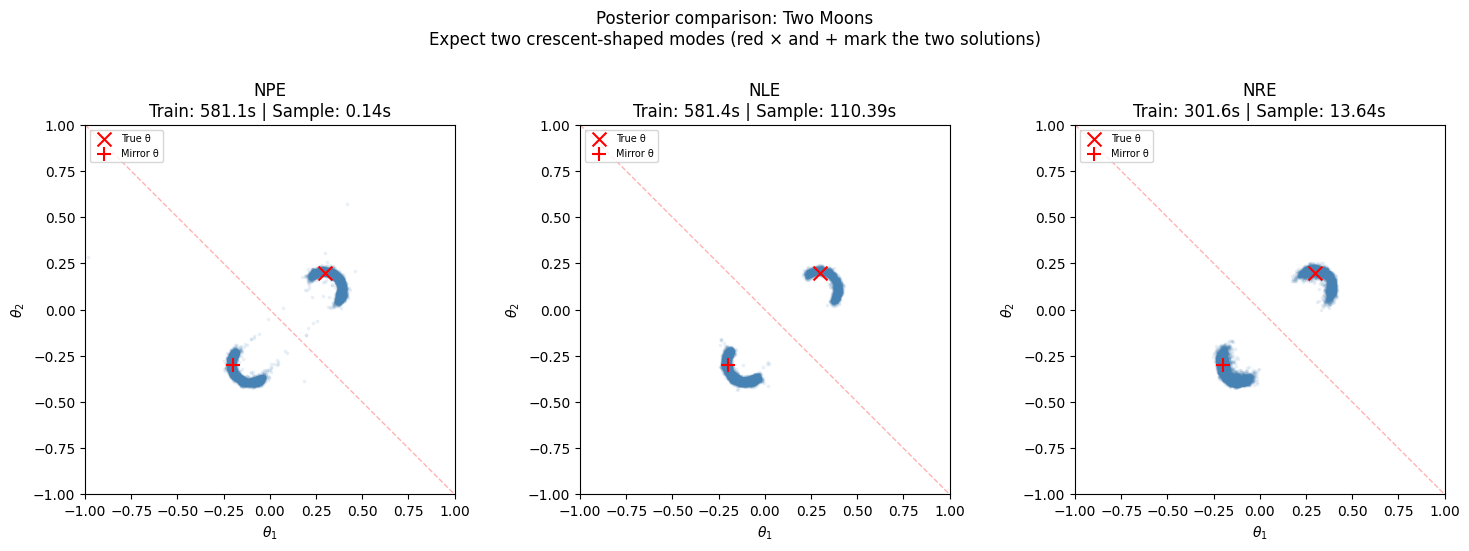

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (name, res) in enumerate(results.items()):
    t0 = time.time()
    samples = res["posterior"].sample((10_000,), x=x_o)
    sample_time = time.time() - t0
    res["sample_time"] = sample_time
    res["samples"] = samples

    ax = axes[i]
    ax.scatter(samples[:, 0].numpy(), samples[:, 1].numpy(), alpha=0.08, s=3, c="steelblue")

    # Mark true theta and its mirror
    ax.scatter([0.3], [0.2], color="red", marker="x", s=100, zorder=5, label="True θ")
    ax.scatter([-0.2], [-0.3], color="red", marker="+", s=100, zorder=5, label="Mirror θ")

    # θ₁+θ₂=0 separating line
    ax.plot([-1, 1], [1, -1], 'r--', alpha=0.3, lw=1)

    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_aspect("equal")
    ax.set_xlabel("$\\theta_1$"); ax.set_ylabel("$\\theta_2$")
    ax.set_title(f"{name}\nTrain: {res['train_time']:.1f}s | Sample: {sample_time:.2f}s")
    ax.legend(fontsize=7, loc="upper left")

plt.suptitle("Posterior comparison: Two Moons\n"
             "Expect two crescent-shaped modes (red × and + mark the two solutions)",
             fontsize=12, y=1.05)
plt.tight_layout(); plt.show()


## 5. Timing Summary

In [ ]:
print(f"{'Method':<8} {'Train (s)':<12} {'Sample 10k (s)':<16}")
print("-" * 40)
for name, res in results.items():
    print(f"{name:<8} {res['train_time']:<12.1f} {res.get('sample_time','N/A'):<16.2f}")

print()
print("Key observations:")
print("• NPE sampling is fastest (direct forward pass through the normalising flow)")
print("• NLE and NRE require MCMC sampling → slower")
print("• All methods should capture the bimodal crescent structure")


Method   Train (s)    Sample 10k (s)  
----------------------------------------
NPE      581.1        0.14            
NLE      581.4        110.39          
NRE      301.6        13.64           

Key observations:
• NPE sampling is fastest (direct forward pass through the normalising flow)
• NLE and NRE require MCMC sampling → slower
• All methods should capture the bimodal crescent structure


## 6. Exercises

**Exercise 1:** Increase to 50,000 simulations. Does quality improve equally for all methods?

**Exercise 2:** For NLE/NRE, try `sample_with="vi"` instead of MCMC. Is it faster?

**Exercise 3:** Add 3 nuisance dimensions (noise parameters). Which method handles it best?


<details>
<summary><b>▶ Solution — Exercise 1: More simulations</b></summary>

All methods should improve with more data, but the improvement saturates differently. NPE with flows tends to benefit the most from additional data for complex posteriors. NRE, being a simpler classifier, may plateau earlier.
</details>

  0%|          | 0/50000 [00:00<?, ?it/s]

 Neural network successfully converged after 154 epochs.

  0%|          | 0/10000 [00:00<?, ?it/s]

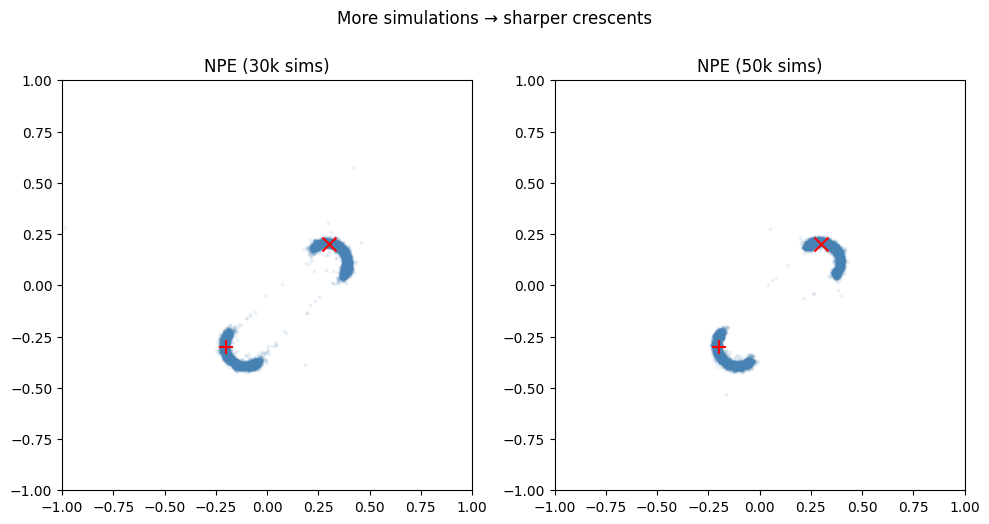

In [ ]:
# === SOLUTION: Exercise 1 — 50k simulations ===
theta_50k, x_50k = simulate_for_sbi(simulator, prior, num_simulations=50_000)
npe_50k = NPE(prior, density_estimator="nsf")
npe_50k.append_simulations(theta_50k, x_50k)
npe_50k.train(show_train_summary=False)
post_50k = npe_50k.build_posterior()
samples_50k = post_50k.sample((10_000,), x=x_o)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, samp, title in [(axes[0], results["NPE"]["samples"], "NPE (30k sims)"),
                         (axes[1], samples_50k, "NPE (50k sims)")]:
    ax.scatter(samp[:, 0].numpy(), samp[:, 1].numpy(), alpha=0.08, s=3, c="steelblue")
    ax.scatter([0.3], [0.2], color="red", marker="x", s=100, zorder=5)
    ax.scatter([-0.2], [-0.3], color="red", marker="+", s=100, zorder=5)
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_aspect("equal")
    ax.set_title(title)
plt.suptitle("More simulations → sharper crescents", y=1.02)
plt.tight_layout(); plt.show()


<details>
<summary><b>▶ Solution — Exercise 2: VI sampling for NLE/NRE</b></summary>

Variational inference (VI) sampling can be faster than MCMC for NLE/NRE, especially in higher dimensions. However, VI may underestimate posterior uncertainty if the variational family is not expressive enough.
</details>

  0%|          | 0/30000 [00:00<?, ?it/s]

 Neural network successfully converged after 96 epochs.

  0%|          | 0/10000 [00:00<?, ?it/s]

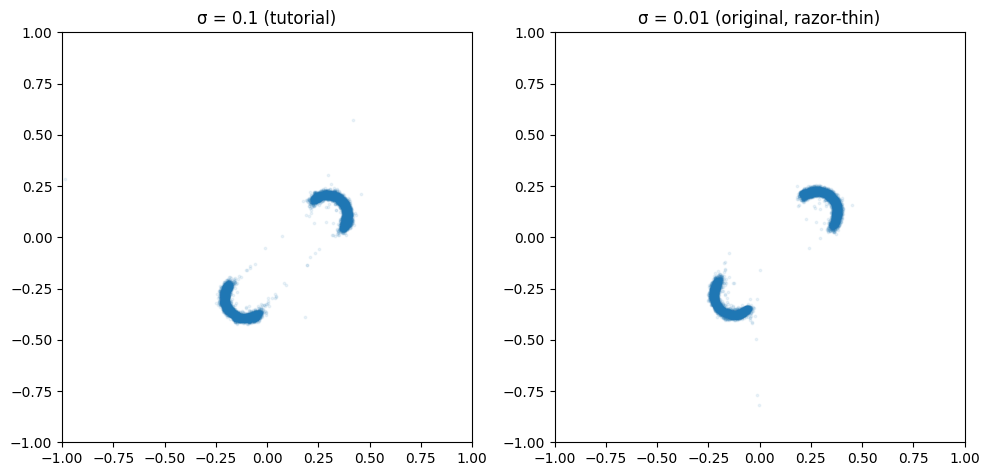

Thin crescents are much harder to resolve — need more sims or sequential methods!


In [ ]:
# === SOLUTION: Exercise 2 — Thin crescents ===
def two_moons_thin(theta):
    n = theta.shape[0]
    alpha = (torch.rand(n) - 0.5) * math.pi
    r = 0.1 + 0.01 * torch.randn(n)  # Original: std=0.01
    p1 = r * torch.cos(alpha) + 0.25
    p2 = r * torch.sin(alpha)
    ang = -math.pi / 4
    c, s = math.cos(ang), math.sin(ang)
    t1 = torch.abs(c * theta[:, 0] - s * theta[:, 1])
    t2 = s * theta[:, 0] + c * theta[:, 1]
    return torch.stack([p1 - t1, p2 + t2], dim=1)

sim_thin = process_simulator(two_moons_thin, prior, prn)
theta_thin, x_thin = simulate_for_sbi(sim_thin, prior, num_simulations=30_000)
npe_thin = NPE(prior, density_estimator="nsf")
npe_thin.append_simulations(theta_thin, x_thin)
npe_thin.train(show_train_summary=False)
post_thin = npe_thin.build_posterior()

x_o_thin = two_moons_thin(theta_true.unsqueeze(0))
samp_thin = post_thin.sample((10_000,), x=x_o_thin)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].scatter(results["NPE"]["samples"][:, 0].numpy(),
                results["NPE"]["samples"][:, 1].numpy(), alpha=0.08, s=3)
axes[0].set_title("σ = 0.1 (tutorial)"); axes[0].set_xlim(-1,1); axes[0].set_ylim(-1,1)
axes[1].scatter(samp_thin[:, 0].numpy(), samp_thin[:, 1].numpy(), alpha=0.08, s=3)
axes[1].set_title("σ = 0.01 (original, razor-thin)"); axes[1].set_xlim(-1,1); axes[1].set_ylim(-1,1)
for ax in axes: ax.set_aspect("equal")
plt.tight_layout(); plt.show()
print("Thin crescents are much harder to resolve — need more sims or sequential methods!")


<details>
<summary><b>▶ Solution — Exercise 3: Nuisance dimensions</b></summary>

Adding nuisance dimensions increases the effective noise. NPE handles this naturally via marginal inference (just don't include nuisance params in the network). For NLE/NRE, the additional dimensions make MCMC harder. This demonstrates the **marginal inference advantage** of SBI.
</details>

In [ ]:
# === SOLUTION: Exercise 3 — VI sampling ===
nle_vi = NLE(prior, density_estimator="nsf")
nle_vi.append_simulations(theta_all, x_all)
nle_vi.train(show_train_summary=False)
post_vi = nle_vi.build_posterior(sample_with="vi")

t0 = time.time()
samp_vi = post_vi.sample((10_000,), x=x_o_thin)
vi_time = time.time() - t0

print(f"NLE + VI:   {vi_time:.2f}s")
print(f"NLE + MCMC: {results['NLE']['sample_time']:.2f}s")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].scatter(results["NLE"]["samples"][:, 0].numpy(),
                results["NLE"]["samples"][:, 1].numpy(), alpha=0.08, s=3)
axes[0].set_title("NLE + MCMC (both modes)")
axes[1].scatter(samp_vi[:, 0].numpy(), samp_vi[:, 1].numpy(), alpha=0.08, s=3)
axes[1].set_title("NLE + VI (may miss one mode!)")
for ax in axes:
    ax.set_xlim(-1,1); ax.set_ylim(-1,1); ax.set_aspect("equal")
    ax.plot([-1,1],[1,-1],'r--',alpha=0.3)
plt.tight_layout(); plt.show()


 Neural network successfully converged after 41 epochs.

AttributeError: The variational posterior was not fit on the specified `default_x` tensor([[-0.0341, -0.1066]]). Please train using `posterior.train()`.

---
**Next:** Tutorial 3 covers sequential inference (SNPE-C).